## Setup

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data/raw/")

In [2]:
# Load all parquet files
tables = {f.stem: pl.read_parquet(f) for f in sorted(DATA_DIR.glob("*.parquet"))}
print("Tables loaded:")
for name, df in tables.items():
    print(f"  {name:30s}  {df.shape[0]:>7,} rows  x  {df.shape[1]:>3} cols")

Tables loaded:
  adl_responses                   480,554 rows  x   12 cols
  care_plans                        3,034 rows  x    9 cols
  diagnoses                        60,620 rows  x    8 cols
  document_tags                   562,905 rows  x    9 cols
  factors                         190,284 rows  x    5 cols
  gg_responses                    660,711 rows  x   10 cols
  hospital_admissions               2,945 rows  x    9 cols
  hospital_transfers                1,816 rows  x   12 cols
  incidents                         3,578 rows  x    8 cols
  injuries                          1,219 rows  x    7 cols
  lab_reports                      13,334 rows  x    9 cols
  medications                     1,430,877 rows  x    8 cols
  needs                           162,762 rows  x   11 cols
  physician_orders                 94,051 rows  x   10 cols
  residents                         3,000 rows  x    9 cols
  therapy_tracks                      761 rows  x    7 cols
  vitals               

## 1. Schema Exploration — Key Tables

In [3]:
KEY_TABLES = ["residents", "incidents", "diagnoses", "medications",
              "vitals", "hospital_admissions", "hospital_transfers",
              "adl_responses", "gg_responses", "factors", "needs",
              "injuries", "lab_reports", "physician_orders", "care_plans"]

for name in KEY_TABLES:
    df = tables[name]
    print(f"\n{'='*60}")
    print(f"  TABLE: {name.upper()}")
    display(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"{'='*60}")
    display(df.schema)
    print("\nNull counts:")
    display(df.null_count())
    print("\nSample (3 rows):")
    display(df.head(3))



  TABLE: RESIDENTS


'  Shape: 3,000 rows x 9 cols'

Schema([('resident_id', String),
        ('facility_id', String),
        ('date_of_birth', Datetime(time_unit='us', time_zone=None)),
        ('admission_date', Datetime(time_unit='us', time_zone=None)),
        ('discharge_date', Datetime(time_unit='us', time_zone=None)),
        ('deceased_date', Datetime(time_unit='us', time_zone=None)),
        ('outpatient', Boolean),
        ('created_at', Datetime(time_unit='us', time_zone=None)),
        ('updated_at', Datetime(time_unit='us', time_zone=None))])


Null counts:


resident_id,facility_id,date_of_birth,admission_date,discharge_date,deceased_date,outpatient,created_at,updated_at
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,2,0,612,2493,0,0,0


...

Schema([('care_plan_id', String),
        ('resident_id', String),
        ('facility_id', String),
        ('initiated_at', Datetime(time_unit='us', time_zone=None)),
        ('closed_reason', String),
        ('closed_at', Datetime(time_unit='us', time_zone=None)),
        ('next_review_at', Datetime(time_unit='us', time_zone=None)),
        ('strikeout', Boolean),
        ('created_at', Datetime(time_unit='us', time_zone=None))])


Null counts:


care_plan_id,resident_id,facility_id,initiated_at,closed_reason,closed_at,next_review_at,strikeout,created_at
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,1116,1116,0,0,0



Sample (3 rows):


care_plan_id,resident_id,facility_id,initiated_at,closed_reason,closed_at,next_review_at,strikeout,created_at
str,str,str,datetime[μs],str,datetime[μs],datetime[μs],bool,datetime[μs]
"""992389a1-ca64-5065-92e8-901fed…","""333ee797-476f-5d73-8a20-02c109…","""018d5b79-b86a-5dc8-8453-417d99…",2025-01-10 01:00:00,null,null,2025-12-01 23:00:00,false,2025-01-10 10:25:09.130
"""7e615ba9-9a72-5f1f-bc46-123ca3…","""3da2879e-983b-5f6b-af78-ac7940…","""018d5b79-b86a-5dc8-8453-417d99…",2025-02-21 01:00:00,null,null,2025-12-22 23:00:00,false,2025-02-21 12:38:04.850
"""7abfd952-1163-5f3d-9804-f1cfbd…","""ecab4119-1ddd-5e42-877c-49c2f0…","""018d5b79-b86a-5dc8-8453-417d99…",2025-01-10 01:00:00,null,null,2025-10-22 00:00:00,false,2025-01-10 12:56:17.260


In [4]:
# Quick look at key tables schemas
for name in ["residents", "incidents", "diagnoses", "medications", "vitals",
             "hospital_admissions", "hospital_transfers", "adl_responses", "gg_responses"]:
    df = tables[name]
    print(f"\n--- {name.upper()} ({df.shape}) ---")
    print(df.schema)



--- RESIDENTS ((3000, 9)) ---
Schema({'resident_id': String, 'facility_id': String, 'date_of_birth': Datetime(time_unit='us', time_zone=None), 'admission_date': Datetime(time_unit='us', time_zone=None), 'discharge_date': Datetime(time_unit='us', time_zone=None), 'deceased_date': Datetime(time_unit='us', time_zone=None), 'outpatient': Boolean, 'created_at': Datetime(time_unit='us', time_zone=None), 'updated_at': Datetime(time_unit='us', time_zone=None)})

--- INCIDENTS ((3578, 8)) ---
Schema({'incident_id': String, 'facility_id': String, 'resident_id': String, 'incident_type': String, 'incident_location': String, 'occurred_at': Datetime(time_unit='us', time_zone=None), 'strikeout': Boolean, 'created_at': Datetime(time_unit='us', time_zone=None)})

--- DIAGNOSES ((60620, 8)) ---
Schema({'diagnosis_id': String, 'facility_id': String, 'resident_id': String, 'icd_10_code': String, 'onset_at': Datetime(time_unit='us', time_zone=None), 'resolved_at': Datetime(time_unit='us', time_zone=None),

## 2. Incidents — Table nalysis

In [5]:
incidents = tables["incidents"]

# Frequency by incident type (excluding strikeouts)
active_incidents = incidents.filter(pl.col("strikeout") == False)
type_counts = (
    active_incidents
    .group_by("incident_type")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print("=== Incident type distribution ===")
print(type_counts)

# Null check
print("\n=== Null counts ===")
print(active_incidents.null_count())

# Time range
print(f"\n=== Date range ===")
print(f"  First: {active_incidents['occurred_at'].min()}")
print(f"  Last:  {active_incidents['occurred_at'].max()}")
print(f"\n  Total active incidents: {len(active_incidents):,}")
print(f"  Strikeout rate: {(incidents['strikeout'].sum() / len(incidents) * 100):.1f}%")


=== Incident type distribution ===
shape: (6, 2)
┌──────────────────┬───────┐
│ incident_type    ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ Fall             ┆ 2505  │
│ Wound            ┆ 589   │
│ Altercation      ┆ 228   │
│ Medication Error ┆ 44    │
│ Choking          ┆ 9     │
│ Elopement        ┆ 7     │
└──────────────────┴───────┘

=== Null counts ===
shape: (1, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ incident_i ┆ facility_i ┆ resident_i ┆ incident_ ┆ incident_ ┆ occurred_ ┆ strikeout ┆ created_a │
│ d          ┆ d          ┆ d          ┆ type      ┆ location  ┆ at        ┆ ---       ┆ t         │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ u32       ┆ ---       │
│ u32        ┆ u32        ┆ u32        ┆ u32       ┆ u32       ┆ u32       ┆           ┆ u32       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════

In [6]:
# RTH events live in hospital_admissions + hospital_transfers
hosp_adm = tables["hospital_admissions"]
hosp_tr  = tables["hospital_transfers"]

print("=== HOSPITAL ADMISSIONS — admission_status values ===")
print(hosp_adm["admission_status"].value_counts().sort("count", descending=True))
print(f"\nEmergency flags: {hosp_adm['emergency_flag'].value_counts()}")

print("\n=== HOSPITAL TRANSFERS — to_from_type / transfer_outcome / stay_purpose ===")
print("to_from_type:")
print(hosp_tr["to_from_type"].value_counts().sort("count", descending=True))
print("\ntransfer_outcome:")
print(hosp_tr["transfer_outcome"].value_counts().sort("count", descending=True))
print("\nstay_purpose:")
print(hosp_tr["stay_purpose"].value_counts().sort("count", descending=True))
print("\nplanned_flag:")
print(hosp_tr["planned_flag"].value_counts())
print("\nemergency_flag:")
print(hosp_tr["emergency_flag"].value_counts())
print(f"\nDate range transfers: {hosp_tr['effective_date'].min()} to {hosp_tr['effective_date'].max()}")
print(f"Date range admissions: {hosp_adm['effective_date'].min()} to {hosp_adm['effective_date'].max()}")


=== HOSPITAL ADMISSIONS — admission_status values ===
shape: (3, 2)
┌───────────────────┬───────┐
│ admission_status  ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ Post Acute        ┆ 1659  │
│ Chronic Long-Term ┆ 1207  │
│ null              ┆ 79    │
└───────────────────┴───────┘

Emergency flags: shape: (1, 2)
┌────────────────┬───────┐
│ emergency_flag ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ null           ┆ 2945  │
└────────────────┴───────┘

=== HOSPITAL TRANSFERS — to_from_type / transfer_outcome / stay_purpose ===
to_from_type:
shape: (15, 2)
┌─────────────────────────┬───────┐
│ to_from_type            ┆ count │
│ ---                     ┆ ---   │
│ str                     ┆ u32   │
╞═════════════════════════╪═══════╡
│ Acute care hospital     ┆ 1314  │
│ Acute care HOSPITAL     ┆ 217   │
│ Hospital                ┆ 84    │
│ Acute hospital          ┆ 81    │
│ Acute Car

In [7]:
# Define RTH events from hospital_transfers (unplanned / emergency return to hospital)
rth_events = hosp_tr.filter(
    (pl.col("to_from_type") == "To Hospital") &
    (pl.col("planned_flag") == False)
)
print(f"Unplanned hospital transfers (RTH proxy): {len(rth_events):,}")
print(rth_events["transfer_reason"].value_counts().sort("count", descending=True))

Unplanned hospital transfers (RTH proxy): 0
shape: (0, 2)
┌─────────────────┬───────┐
│ transfer_reason ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
└─────────────────┴───────┘


In [8]:
# Investigate actual content of hospital_transfers more carefully
print("Sample hospital_transfers:")
print(hosp_tr.head(10))
print("\nAll unique to_from_type:")
print(hosp_tr["to_from_type"].unique())
print("\nAll unique planned_flag values:")
print(hosp_tr["planned_flag"].unique())
print("\nAll unique emergency_flag values:")
print(hosp_tr["emergency_flag"].unique())
print("\nAll unique transfer_reason values (sample):")
print(hosp_tr["transfer_reason"].value_counts().sort("count", descending=True).head(20))


Sample hospital_transfers:
shape: (10, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ transfer_ ┆ facility_ ┆ resident_ ┆ effective ┆ … ┆ transfer_ ┆ planned_f ┆ emergency ┆ created_ │
│ id        ┆ id        ┆ id        ┆ _date     ┆   ┆ reason    ┆ lag       ┆ _flag     ┆ at       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ str       ┆ str       ┆ datetime[ ┆   ┆ str       ┆ bool      ┆ bool      ┆ datetime │
│           ┆           ┆           ┆ μs]       ┆   ┆           ┆           ┆           ┆ [μs]     │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 568a2f5c- ┆ 0240d706- ┆ 87db939c- ┆ 2024-11-1 ┆ … ┆ Nausea/vo ┆ false     ┆ false     ┆ 2024-11- │
│ 4bc9-5919 ┆ 3348-5117 ┆ 33d3-57c2 ┆ 0         ┆   ┆ miting    ┆           ┆           ┆ 11 08:53 │
│ -a588-e7e ┆ -8d03-b06 ┆ -bdd0-467 ┆ 11:30:00  

In [9]:
# Check emergency_flag True transfers and admission_status for RTH identification
print("=== Transfers with emergency_flag = True ===")
print(hosp_tr.filter(pl.col("emergency_flag") == True).shape)
print(hosp_tr.filter(pl.col("emergency_flag") == True).select(["to_from_type","transfer_outcome","stay_purpose","transfer_reason","planned_flag"]).head(10))

print("\n=== Hospital admissions with emergency_flag = True ===")
emerg_adm = hosp_adm.filter(pl.col("emergency_flag") == True)
print(f"Count: {len(emerg_adm):,}")
print(emerg_adm.head(10))

print("\n=== Hospital admissions: all unique admission_status ===")
print(hosp_adm["admission_status"].unique())

# RTH = "To Hospital" transfers with emergency_flag OR transfers where resident returns to hospital after SNF stay
print("\n=== All to_from_type 'To Hospital' transfers ===")
to_hosp = hosp_tr.filter(pl.col("to_from_type") == "To Hospital")
print(f"Count: {len(to_hosp):,}")
print(to_hosp.select(["planned_flag","emergency_flag","transfer_outcome","transfer_reason"]).head(20))


=== Transfers with emergency_flag = True ===
(303, 12)
shape: (10, 5)
┌──────────────┬────────────────────────┬───────────────────┬───────────────────────┬──────────────┐
│ to_from_type ┆ transfer_outcome       ┆ stay_purpose      ┆ transfer_reason       ┆ planned_flag │
│ ---          ┆ ---                    ┆ ---               ┆ ---                   ┆ ---          │
│ str          ┆ str                    ┆ str               ┆ str                   ┆ bool         │
╞══════════════╪════════════════════════╪═══════════════════╪═══════════════════════╪══════════════╡
│ Acute care   ┆ Admitted, Inpatient    ┆ Chronic Long-Term ┆ Fall                  ┆ false        │
│ hospital     ┆                        ┆                   ┆                       ┆              │
│ Acute care   ┆ Admitted, Inpatient    ┆ Chronic Long-Term ┆ Shortness of Breath   ┆ false        │
│ hospital     ┆                        ┆                   ┆ (bronchiti…           ┆              │
│ Acute Care   ┆ null

In [10]:
# Understand transfer patterns better - check actual column values
print("=== hospital_transfers sample (5 rows, transposed) ===")
for row in hosp_tr.head(5).iter_rows(named=True):
    for k, v in row.items():
        print(f"  {k}: {v}")
    print()

print("=== hospital_admissions sample (5 rows, transposed) ===")
for row in hosp_adm.head(5).iter_rows(named=True):
    for k, v in row.items():
        print(f"  {k}: {v}")
    print()

# Count RTH via emergency_flag in hospital_admissions
rth_adm = hosp_adm.filter(pl.col("emergency_flag") == True)
print(f"\nEmergency hospital admissions (RTH candidate): {len(rth_adm):,} out of {len(hosp_adm):,}")

# Count RTH via transfer (any "To Hospital" transfer)
to_hosp_all = hosp_tr.filter(pl.col("to_from_type") == "To Hospital")
print(f"Any 'To Hospital' transfer: {len(to_hosp_all):,} out of {len(hosp_tr):,}")


=== hospital_transfers sample (5 rows, transposed) ===
  transfer_id: 568a2f5c-4bc9-5919-a588-e7e2f944f3cc
  facility_id: 0240d706-3348-5117-8d03-b06c5141e8c0
  resident_id: 87db939c-33d3-57c2-bdd0-467a0a3a5b27
  effective_date: 2024-11-10 11:30:00
  ineffective_date: 2024-11-19 10:29:00
  to_from_type: Acute care hospital
  transfer_outcome: Admitted, Inpatient
  stay_purpose: Chronic Long-Term
  transfer_reason: Nausea/vomiting
  planned_flag: False
  emergency_flag: False
  created_at: 2024-11-11 08:53:38.333000

  transfer_id: 158bea4f-9fc7-505a-b163-97f3ac65e6fb
  facility_id: 0240d706-3348-5117-8d03-b06c5141e8c0
  resident_id: 64a69f92-102f-5f4b-81f4-137a9498c409
  effective_date: 2024-09-09 11:22:00
  ineffective_date: 2024-09-09 11:22:00
  to_from_type: Acute care hospital
  transfer_outcome: Admitted, Status Uncertain
  stay_purpose: Post Acute
  transfer_reason: Fall
  planned_flag: False
  emergency_flag: False
  created_at: 2024-09-09 15:50:48.123000

  transfer_id: a7b06dc

In [11]:
# Correct RTH definition: all hospital transfers (to_from_type is the hospital TYPE, not direction)
# Unplanned = planned_flag is False or null
rth = hosp_tr.filter(
    (pl.col("planned_flag") == False) | (pl.col("planned_flag").is_null())
)
print(f"Total hospital transfers: {len(hosp_tr):,}")
print(f"Unplanned transfers (RTH): {len(rth):,}  ({len(rth)/len(hosp_tr)*100:.1f}%)")
print(f"Emergency transfers: {hosp_tr['emergency_flag'].sum():,}")
print(f"Unique residents with any transfer: {hosp_tr['resident_id'].n_unique():,} / {tables['residents']['resident_id'].n_unique():,}")
print(f"\nTransfer outcome breakdown:")
print(hosp_tr["transfer_outcome"].value_counts().sort("count", descending=True))
print(f"\nTop 15 transfer reasons:")
print(hosp_tr["transfer_reason"].value_counts().sort("count", descending=True).head(15))


Total hospital transfers: 1,816
Unplanned transfers (RTH): 1,770  (97.5%)
Emergency transfers: 303
Unique residents with any transfer: 911 / 3,000

Transfer outcome breakdown:
shape: (6, 2)
┌────────────────────────────┬───────┐
│ transfer_outcome           ┆ count │
│ ---                        ┆ ---   │
│ str                        ┆ u32   │
╞════════════════════════════╪═══════╡
│ Admitted, Inpatient        ┆ 738   │
│ null                       ┆ 515   │
│ ED Visit Only              ┆ 251   │
│ Admitted, Status Uncertain ┆ 149   │
│ Other                      ┆ 101   │
│ Admitted, Observation      ┆ 62    │
└────────────────────────────┴───────┘

Top 15 transfer reasons:
shape: (15, 2)
┌─────────────────────────────────┬───────┐
│ transfer_reason                 ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Other                           ┆ 474   │
│ null                            ┆ 3

## 3. Residents — Demographics & Stay Analysis

In [12]:
residents = tables["residents"]

# Age at admission (use date_of_birth and admission_date)
res_with_age = residents.with_columns([
    ((pl.col("admission_date").cast(pl.Date) - pl.col("date_of_birth").cast(pl.Date)).dt.total_days() / 365.25)
    .alias("age_at_admission"),
    (pl.col("discharge_date").is_not_null()).alias("discharged"),
    (pl.col("deceased_date").is_not_null()).alias("deceased"),
]).with_columns([
    pl.when(pl.col("discharge_date").is_not_null())
      .then((pl.col("discharge_date").cast(pl.Date) - pl.col("admission_date").cast(pl.Date)).dt.total_days())
      .otherwise(None)
      .alias("los_days"),  # length of stay in days
])

print("=== Age at admission (years) ===")
age_desc = res_with_age["age_at_admission"].describe()
print(age_desc)

print("\n=== Length of Stay distribution (days, discharged residents only) ===")
print(res_with_age.filter(pl.col("los_days").is_not_null())["los_days"].describe())

print("\n=== Resident status ===")
print(f"  Total residents:   {len(residents):,}")
print(f"  Discharged:        {res_with_age['discharged'].sum():,}")
print(f"  Deceased:          {res_with_age['deceased'].sum():,}")
print(f"  Outpatient:        {residents['outpatient'].sum():,}")
print(f"  Active (not discharged): {(~res_with_age['discharged']).sum():,}")

print(f"\n=== Facilities ===")
print(f"  Unique facilities: {residents['facility_id'].n_unique():,}")
print(residents.group_by("facility_id").agg(pl.len().alias("residents")).sort("residents", descending=True).head(10))


=== Age at admission (years) ===
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 2998.0     │
│ null_count ┆ 2.0        │
│ mean       ┆ 74.359445  │
│ std        ┆ 12.514992  │
│ min        ┆ 23.556468  │
│ 25%        ┆ 66.16564   │
│ 50%        ┆ 75.427789  │
│ 75%        ┆ 83.509925  │
│ max        ┆ 104.429843 │
└────────────┴────────────┘

=== Length of Stay distribution (days, discharged residents only) ===
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 2388.0     │
│ null_count ┆ 0.0        │
│ mean       ┆ 198.295645 │
│ std        ┆ 468.260121 │
│ min        ┆ -1.0       │
│ 25%        ┆ 13.0       │
│ 50%        ┆ 31.0       │
│ 75%        ┆ 118.0      │
│ max        ┆ 5904.0     │
└────────────┴────────────┘

=== Resident status ===
  T

In [13]:

# Incidents per resident — label imbalance assessment
incident_counts = (
    active_incidents
    .group_by("resident_id")
    .agg(pl.len().alias("n_incidents"))
)
all_residents = residents.select("resident_id")
incident_rate = all_residents.join(incident_counts, on="resident_id", how="left").with_columns(
    pl.col("n_incidents").fill_null(0)
)
has_incident = incident_rate.filter(pl.col("n_incidents") > 0)
has_fall = (
    active_incidents
    .filter(pl.col("incident_type") == "Fall")
    .group_by("resident_id")
    .agg(pl.len().alias("n_falls"))
)

print("=== Incident prevalence per resident ===")
print(f"  Residents with ANY incident:   {len(has_incident):,} / {len(residents):,}  ({len(has_incident)/len(residents)*100:.1f}%)")
fall_res = active_incidents.filter(pl.col("incident_type") == "Fall")["resident_id"].n_unique()
wound_res = active_incidents.filter(pl.col("incident_type") == "Wound")["resident_id"].n_unique()
alt_res = active_incidents.filter(pl.col("incident_type") == "Altercation")["resident_id"].n_unique()
print(f"  Residents with Fall incident:  {fall_res:,}  ({fall_res/len(residents)*100:.1f}%)")
print(f"  Residents with Wound incident: {wound_res:,}  ({wound_res/len(residents)*100:.1f}%)")
print(f"  Residents with Altercation:    {alt_res:,}  ({alt_res/len(residents)*100:.1f}%)")
print(f"  Residents with RTH transfer:   {tables['hospital_transfers']['resident_id'].n_unique():,}  ({tables['hospital_transfers']['resident_id'].n_unique()/len(residents)*100:.1f}%)")

print("\n=== Incidents per resident distribution (among those with any) ===")
print(incident_rate.filter(pl.col("n_incidents") > 0)["n_incidents"].describe())


=== Incident prevalence per resident ===
  Residents with ANY incident:   978 / 3,000  (32.6%)
  Residents with Fall incident:  806  (26.9%)
  Residents with Wound incident: 299  (10.0%)
  Residents with Altercation:    127  (4.2%)
  Residents with RTH transfer:   911  (30.4%)

=== Incidents per resident distribution (among those with any) ===
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 978.0    │
│ null_count ┆ 0.0      │
│ mean       ┆ 3.458078 │
│ std        ┆ 4.651936 │
│ min        ┆ 1.0      │
│ 25%        ┆ 1.0      │
│ 50%        ┆ 2.0      │
│ 75%        ┆ 4.0      │
│ max        ┆ 46.0     │
└────────────┴──────────┘


## 4. Visualizations — Incident & Transfer Distributions

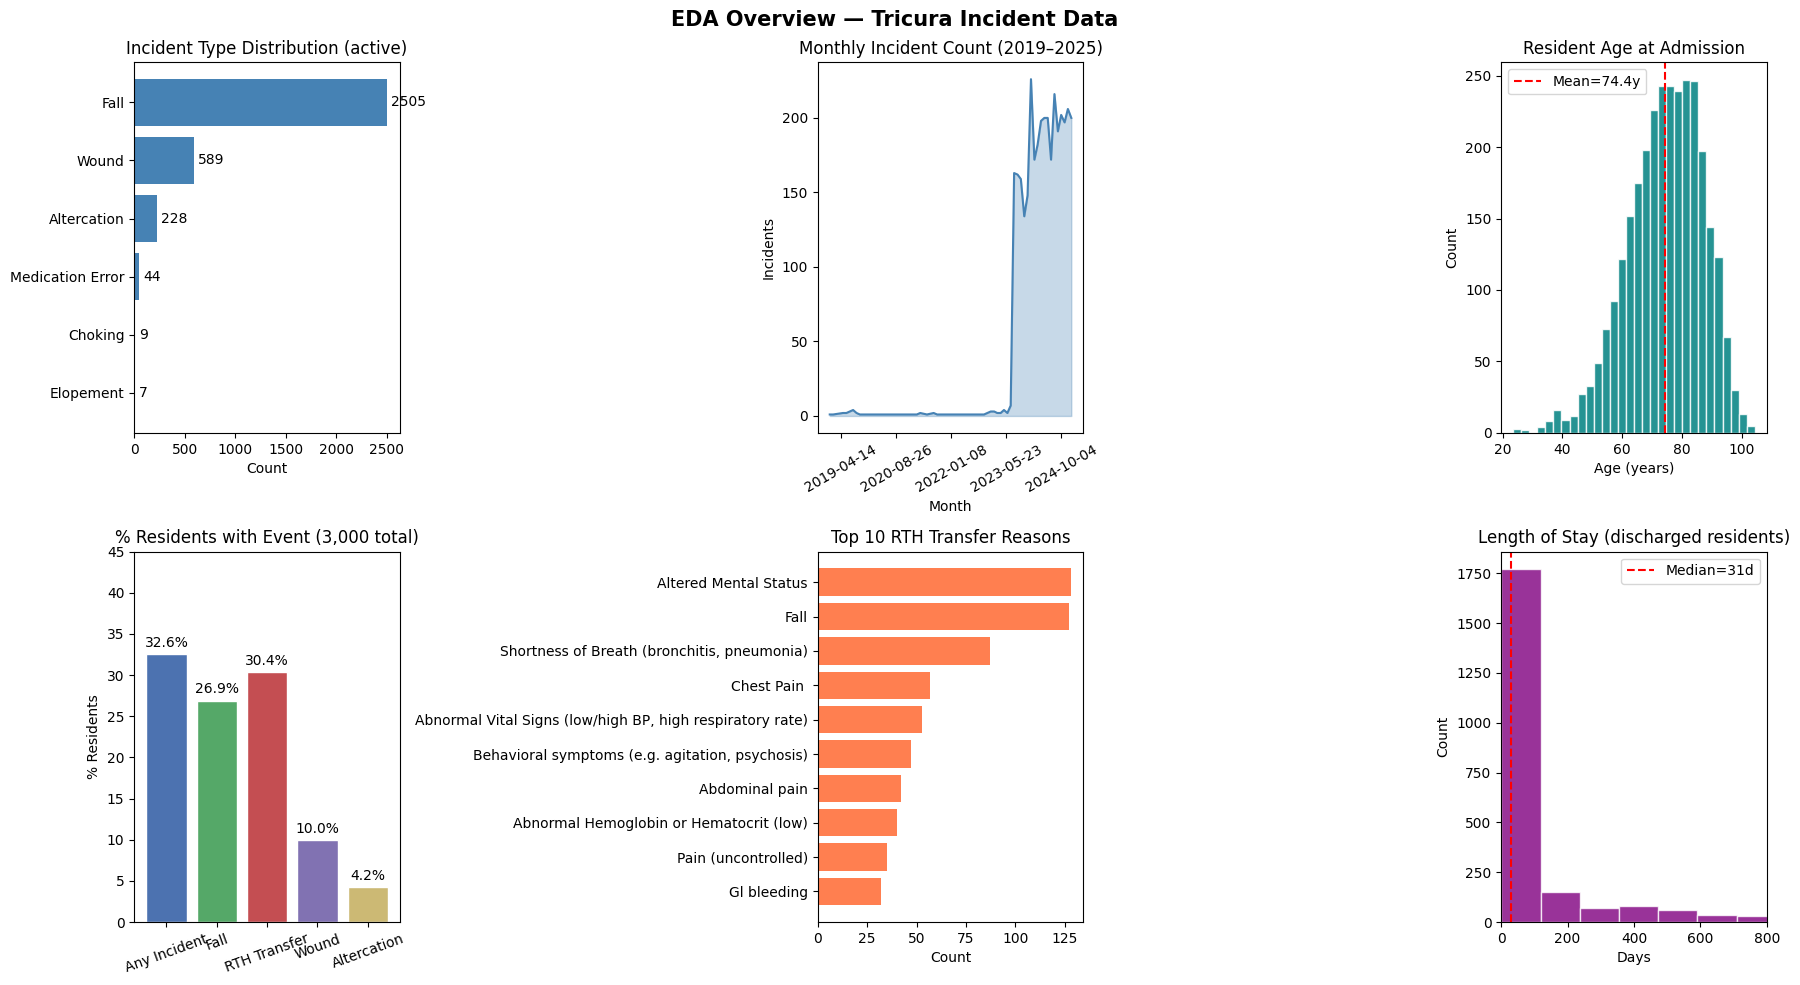

Figure saved.


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA Overview — Tricura Incident Data", fontsize=15, fontweight="bold")

# ── 1. Incident type distribution ──────────────────────────────────────────
ax = axes[0, 0]
tc = type_counts.sort("count", descending=True)
bars = ax.barh(tc["incident_type"].to_list(), tc["count"].to_list(), color="steelblue")
ax.bar_label(bars, padding=3)
ax.set_title("Incident Type Distribution (active)")
ax.set_xlabel("Count")
ax.invert_yaxis()

# ── 2. Incidents over time (monthly) ───────────────────────────────────────
ax = axes[0, 1]
monthly = (
    active_incidents
    .with_columns(pl.col("occurred_at").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg(pl.len().alias("count"))
    .sort("month")
    .filter(pl.col("month") >= pl.datetime(2019, 1, 1))
)
months = monthly["month"].to_list()
counts = monthly["count"].to_list()
ax.plot(months, counts, color="steelblue", linewidth=1.5)
ax.fill_between(months, counts, alpha=0.3, color="steelblue")
ax.set_title("Monthly Incident Count (2019–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Incidents")
ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# ── 3. Resident age distribution ───────────────────────────────────────────
ax = axes[0, 2]
age_vals = res_with_age["age_at_admission"].drop_nulls().to_list()
ax.hist(age_vals, bins=30, color="teal", edgecolor="white", alpha=0.85)
ax.axvline(x=74.4, color="red", linestyle="--", linewidth=1.5, label="Mean=74.4y")
ax.set_title("Resident Age at Admission")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
ax.legend()

# ── 4. Prevalence summary — resident-level ────────────────────────────────
ax = axes[1, 0]
labels  = ["Any Incident", "Fall", "RTH Transfer", "Wound", "Altercation"]
values  = [32.6, 26.9, 30.4, 10.0, 4.2]
colors  = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
bars = ax.bar(labels, values, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax.set_title("% Residents with Event (3,000 total)")
ax.set_ylabel("% Residents")
ax.set_ylim(0, 45)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20)

# ── 5. RTH transfer reasons (top 10, excluding null/Other) ─────────────────
ax = axes[1, 1]
rth_reasons = (
    hosp_tr
    .filter(pl.col("transfer_reason").is_not_null() & (pl.col("transfer_reason") != "Other"))
    .group_by("transfer_reason")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(10)
)
ax.barh(rth_reasons["transfer_reason"].to_list(), rth_reasons["count"].to_list(), color="coral")
ax.set_title("Top 10 RTH Transfer Reasons")
ax.set_xlabel("Count")
ax.invert_yaxis()

# ── 6. Length of stay distribution ────────────────────────────────────────
ax = axes[1, 2]
los_vals = res_with_age.filter(pl.col("los_days").is_not_null() & (pl.col("los_days") > 0))["los_days"].to_list()
ax.hist(los_vals, bins=50, color="purple", edgecolor="white", alpha=0.8)
ax.axvline(x=31, color="red", linestyle="--", linewidth=1.5, label="Median=31d")
ax.set_title("Length of Stay (discharged residents)")
ax.set_xlabel("Days")
ax.set_ylabel("Count")
ax.set_xlim(0, 800)
ax.legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 5. Clinical Features — Diagnoses, Medications, Vitals, ADL/GG

In [15]:
# ── 5a. Diagnoses — top ICD-10 codes and coverage ─────────────────────────
diag = tables["diagnoses"]
active_diag = diag.filter(pl.col("strikeout") == False)

print("=== DIAGNOSES ===")
print(f"Total records: {len(diag):,}  |  Active: {len(active_diag):,}")
print(f"Unique residents with diagnoses: {active_diag['resident_id'].n_unique():,} / 3,000")
print(f"Mean active diagnoses per resident: {len(active_diag) / active_diag['resident_id'].n_unique():.1f}")
print(f"\nTop 20 ICD-10 codes (active):")

# Map key ICD codes to readable names
ICD_LABELS = {
    "M62.81": "Sarcopenia",
    "I10":    "Hypertension",
    "E78.5":  "Hyperlipidemia",
    "Z74.1":  "Personal care assistance needed",
    "R26.2":  "Difficulty walking",
    "M79.3":  "Panniculitis",
    "Z87.39": "Personal hx other musculoskeletal",
    "E11.9":  "Type 2 Diabetes",
    "U07.1":  "COVID-19",
    "J44.9":  "COPD unspecified",
    "R27.8":  "Other lack of coordination",
    "R26.89": "Other abnormalities of gait/mobility",
}

top_diag = (
    active_diag
    .group_by("icd_10_code")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(20)
    .with_columns(
        pl.col("icd_10_code").replace(ICD_LABELS, default=None).alias("description")
    )
)
print(top_diag)


=== DIAGNOSES ===
Total records: 60,620  |  Active: 58,067
Unique residents with diagnoses: 2,547 / 3,000
Mean active diagnoses per resident: 22.8

Top 20 ICD-10 codes (active):
shape: (20, 3)
┌─────────────┬───────┬─────────────────────────────────┐
│ icd_10_code ┆ count ┆ description                     │
│ ---         ┆ ---   ┆ ---                             │
│ str         ┆ u32   ┆ str                             │
╞═════════════╪═══════╪═════════════════════════════════╡
│ M62.81      ┆ 2169  ┆ Sarcopenia                      │
│ I10         ┆ 1735  ┆ Hypertension                    │
│ E78.5       ┆ 1225  ┆ Hyperlipidemia                  │
│ Z74.1       ┆ 954   ┆ Personal care assistance neede… │
│ R26.2       ┆ 894   ┆ Difficulty walking              │
│ …           ┆ …     ┆ …                               │
│ D64.9       ┆ 489   ┆ null                            │
│ E03.9       ┆ 482   ┆ null                            │
│ R13.12      ┆ 465   ┆ null                         

In [16]:
# ── 5b. Medications ─────────────────────────────────────────────────────────
meds = tables["medications"]
print("=== MEDICATIONS ===")
print(f"Total records: {len(meds):,}  |  Unique residents: {meds['resident_id'].n_unique():,}")
print(f"Coverage: {meds['resident_id'].n_unique() / len(residents) * 100:.1f}% of residents have medication records")
print(f"\nMedication status breakdown:")
print(meds["status"].value_counts().sort("count", descending=True))
missed_rate = meds.filter(pl.col("status") == "Missed").shape[0] / len(meds) * 100
refused_rate = meds.filter(pl.col("status") == "Refused").shape[0] / len(meds) * 100
print(f"\nMissed rate: {missed_rate:.1f}%  |  Refused rate: {refused_rate:.1f}%")

# Polypharmacy proxy: count distinct medications per resident
polypharmacy = (
    meds
    .group_by("resident_id")
    .agg(pl.col("description").n_unique().alias("n_unique_meds"))
    .sort("n_unique_meds", descending=True)
)
print(f"\nPolypharmacy (unique medications per resident):")
print(polypharmacy["n_unique_meds"].describe())
print(f"  Residents with >10 unique meds: {polypharmacy.filter(pl.col('n_unique_meds') > 10).shape[0]}")
print(f"  Residents with >20 unique meds: {polypharmacy.filter(pl.col('n_unique_meds') > 20).shape[0]}")


=== MEDICATIONS ===
Total records: 1,430,877  |  Unique residents: 481
Coverage: 16.0% of residents have medication records

Medication status breakdown:
shape: (4, 2)
┌─────────┬────────┐
│ status  ┆ count  │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ On Time ┆ 805482 │
│ Late    ┆ 513171 │
│ Missed  ┆ 102346 │
│ Refused ┆ 9878   │
└─────────┴────────┘

Missed rate: 7.2%  |  Refused rate: 0.7%

Polypharmacy (unique medications per resident):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 481.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 46.804574 │
│ std        ┆ 36.739274 │
│ min        ┆ 1.0       │
│ 25%        ┆ 25.0      │
│ 50%        ┆ 37.0      │
│ 75%        ┆ 54.0      │
│ max        ┆ 347.0     │
└────────────┴───────────┘
  Residents with >10 unique meds: 473
  Residents with >20 unique meds: 409


In [17]:
# ── 5c. Vitals ──────────────────────────────────────────────────────────────
vitals = tables["vitals"]
print("=== VITALS ===")
print(f"Total records: {len(vitals):,}  |  Unique residents: {vitals['resident_id'].n_unique():,}")
print(f"Vitals strikeout rate: {vitals['strikeout'].sum() / len(vitals) * 100:.2f}%")
print(f"\nVital type counts:")
print(vitals["vital_type"].value_counts().sort("count", descending=True))
print(f"\nVitals date range: {vitals['measured_at'].min()} — {vitals['measured_at'].max()}")

# Stats on BP-Systolic (key for RTH)
bp = vitals.filter((pl.col("vital_type") == "BP - Systolic") & (pl.col("strikeout") == False))
print(f"\n=== BP Systolic stats ===")
print(bp["value"].cast(pl.Float64, strict=False).describe())

# O2 sats stats
o2 = vitals.filter((pl.col("vital_type") == "O2 sats") & (pl.col("strikeout") == False))
print(f"\n=== O2 Saturation stats ===")
print(o2["value"].cast(pl.Float64, strict=False).describe())


=== VITALS ===
Total records: 2,517,056  |  Unique residents: 2,464
Vitals strikeout rate: 0.17%

Vital type counts:
shape: (8, 2)
┌───────────────┬────────┐
│ vital_type    ┆ count  │
│ ---           ┆ ---    │
│ str           ┆ u32    │
╞═══════════════╪════════╡
│ Pain Level    ┆ 831372 │
│ BP - Systolic ┆ 370662 │
│ Pulse         ┆ 336209 │
│ O2 sats       ┆ 266805 │
│ Blood Sugar   ┆ 250563 │
│ Temperature   ┆ 238352 │
│ Respiration   ┆ 189396 │
│ Weight        ┆ 33697  │
└───────────────┴────────┘

Vitals date range: 2023-07-01 00:04:00 — 2025-01-31 23:59:51

=== BP Systolic stats ===
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 370019.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ 128.150164 │
│ std        ┆ 33.937384  │
│ min        ┆ 0.0        │
│ 25%        ┆ 118.0      │
│ 50%        ┆ 128.0      │
│ 75%        ┆ 136.0      │
│ max        ┆ 13385.0  

In [18]:
# ── 5d. ADL & GG Functional Status ─────────────────────────────────────────
adl = tables["adl_responses"]
gg  = tables["gg_responses"]

print("=== ADL RESPONSES (MDS standard) ===")
print(f"Total: {len(adl):,}  |  Unique residents: {adl['resident_id'].n_unique():,}")
print(f"Date range: {adl['assessment_date'].min()} — {adl['assessment_date'].max()}")
print(f"\nUnique ADL activities ({adl['activity'].n_unique()}):")
print(adl["activity"].unique().to_list())
print(f"\nADL response scale (0=Independent, 4=Total Dependence, n/a=Activity did not occur):")
print(adl["response"].value_counts().sort("count", descending=True))

# Average ADL score per resident (mobility-related activities only, numeric responses)
mobility_adl = ["Bed mobility - Self-Performance", "Transfer - Self-Performance",
                "Walking in room - Self-Performance", "Walking in corridor - Self-Performance"]
adl_mobility = (
    adl
    .filter(
        pl.col("activity").is_in(mobility_adl) &
        pl.col("response").is_in(["0","1","2","3","4"])
    )
    .with_columns(pl.col("response").cast(pl.Float64).alias("resp_num"))
    .group_by("resident_id")
    .agg(pl.col("resp_num").mean().alias("mean_mobility_adl"))
)
print(f"\n=== Mean Mobility ADL Score per resident (0=independent, 4=dependent) ===")
print(adl_mobility["mean_mobility_adl"].describe())

print("\n=== GG RESPONSES (CMS Standardized Patient Assessment) ===")
print(f"Total: {len(gg):,}  |  Unique residents: {gg['resident_id'].n_unique():,}")
print(f"Task groups: {gg['task_group'].unique().to_list()}")
print(f"\nGG response_code scale (6=Independent, 1=Dependent, 9=Not attempted):")
print(gg["response_code"].value_counts().sort("count", descending=True))


=== ADL RESPONSES (MDS standard) ===
Total: 480,554  |  Unique residents: 96
Date range: 2024-04-26 00:00:00 — 2025-01-31 00:00:00

Unique ADL activities (22):
['Dressing - Support', 'Locomotion on unit - Self-Performance', 'Bathing - Self-Performance', 'Locomotion off unit - Support', 'Toilet use - Support', 'Walk in corridor - Support', 'Walk in room - Self-Performance', 'Dressing - Self-Performance', 'Transfer - Self-Performance', 'Personal hygiene - Support', 'Locomotion off unit - Self-Performance', 'Locomotion on unit - Support', 'Toilet use - Self-Performance', 'Walk in corridor - Self-Performance', 'Bathing - Support', 'Personal hygiene - Self-Performance', 'Eating - Support', 'Walk in room - Support', 'Transfer - Support', 'Eating - Self-Performance', 'Bed mobility - Self-Performance', 'Bed mobility - Support']

ADL response scale (0=Independent, 4=Total Dependence, n/a=Activity did not occur):
shape: (7, 2)
┌──────────┬────────┐
│ response ┆ count  │
│ ---      ┆ ---    │
│ s

In [19]:
# ── 5e. Feature coverage matrix ─────────────────────────────────────────────
feature_coverage = {
    "Table":            ["residents",  "incidents",      "diagnoses",  "medications", "vitals",    "adl_responses", "gg_responses", "hospital_transfers"],
    "# Rows":           [3_000,        3_578,            60_620,       1_430_877,     2_517_056,   480_554,         660_711,        1_816],
    "# Residents":      [3_000,        active_incidents["resident_id"].n_unique(),
                                                         2_547,        481,           2_464,       96,              134,            911],
    "Coverage %":       [100.0,        round(active_incidents["resident_id"].n_unique()/3000*100,1),
                                                         round(2547/3000*100,1),
                                                                       round(481/3000*100,1),
                                                                                      round(2464/3000*100,1),
                                                                                                   round(96/3000*100,1),
                                                                                                                    round(134/3000*100,1),
                                                                                                                                    round(911/3000*100,1)],
    "Date Range (approx)": [
        "2006–2025", "2019–2025", "2019–2025", "2023–2025",
        "2023–2025", "2024–2025", "2023–2025", "2006–2025"
    ]
}
import polars as pl
coverage_df = pl.DataFrame(feature_coverage)
print("=== Feature Coverage Matrix ===")
print(coverage_df)
print()
print("Key insight: vitals (2.5M rows), diagnoses (58k rows), hospital_transfers best coverage.")
print("medications only covers 16% of residents — note medications may be from a subset of facilities.")
print("ADL/GG: very limited recent data (96/134 residents); useful for the available window.")


=== Feature Coverage Matrix ===
shape: (8, 5)
┌────────────────────┬─────────┬─────────────┬────────────┬─────────────────────┐
│ Table              ┆ # Rows  ┆ # Residents ┆ Coverage % ┆ Date Range (approx) │
│ ---                ┆ ---     ┆ ---         ┆ ---        ┆ ---                 │
│ str                ┆ i64     ┆ i64         ┆ f64        ┆ str                 │
╞════════════════════╪═════════╪═════════════╪════════════╪═════════════════════╡
│ residents          ┆ 3000    ┆ 3000        ┆ 100.0      ┆ 2006–2025           │
│ incidents          ┆ 3578    ┆ 978         ┆ 32.6       ┆ 2019–2025           │
│ diagnoses          ┆ 60620   ┆ 2547        ┆ 84.9       ┆ 2019–2025           │
│ medications        ┆ 1430877 ┆ 481         ┆ 16.0       ┆ 2023–2025           │
│ vitals             ┆ 2517056 ┆ 2464        ┆ 82.1       ┆ 2023–2025           │
│ adl_responses      ┆ 480554  ┆ 96          ┆ 3.2        ┆ 2024–2025           │
│ gg_responses       ┆ 660711  ┆ 134         ┆ 4.5  

## 6. Hypotheses & Modeling Plan (Revised)

### Business Context Recap

The goal is to **reduce the frequency and severity of incidents** at insured facilities, which directly reduces claims below premiums collected.

| Incident Type | % Claims | Avg Cost | Count in Data | Time Horizon |
|---|---|---|---|---|
| Falls | ~13% | ~$3,500 | **2,505** ✓ | **7 days** |
| Medication errors | ~10% | ~$5,000 | 44 (low) | **7 days** |
| Wounds / pressure injuries | ~7% | ~$4,000 | **589** ✓ | **14 days** |
| Return-to-hospital (RTH) | ~7% | **~$20,000** | **1,816 transfers** ✓ | **7 days** |
| Elopement / wandering | ~5% | ~$2,500 | 7 (too low) | **30 days** |
| Altercations | ~2% | ~$2,500 | **228** ✓ | **7 days** |

---

### Class Imbalance Under New Time Horizons

With **weekly observation windows** (vitals window: Jul 2023–Jan 2025, ~82 weeks, ~3,000 residents):

| Target | Events | Obs. Windows (approx) | Positive Rate | Neg:Pos | ML Feasibility |
|---|---|---|---|---|---|
| Falls (7d) | 2,454 | ~246,000 | ~1.0% | ~100:1 | ✅ Feasible |
| RTH (7d) | 1,703 | ~246,000 | ~0.69% | ~145:1 | ✅ Feasible |
| Wounds (14d) | ~500 | ~123,000 | ~0.41% | ~245:1 | ✅ Feasible (harder) |
| Altercations (7d) | ~180 | ~246,000 | ~0.07% | ~1,400:1 | ⚠️ Borderline |
| Med Errors (7d) | ~35 | ~246,000 | ~0.014% | ~7,000:1 | ❌ Impossible |
| Choking (7d) | ~8 | ~246,000 | ~0.003% | ~30,000:1 | ❌ Impossible |
| Elopement (30d) | 7 | ~57,000 | ~0.012% | ~8,000:1 | ❌ Impossible |

**Key insight:** The shorter time horizons (7d vs. 30d) increase imbalance ~4× compared to original plan. Falls and RTH remain feasible; wounds are harder but still workable. Altercations are borderline. The remaining three types are statistically impossible for supervised ML.

---

### Modeling Tiers

#### Tier 1 — Full ML Binary Classifiers (sufficient data)

| Model | Target | Horizon | Events | Approach |
|---|---|---|---|---|
| **H1** | Fall | 7 days | 2,505 | LightGBM + SHAP |
| **H2** | RTH (unplanned transfer) | 7 days | 1,770 | LightGBM + SHAP |
| **H3** | Wound / Pressure Injury | 14 days | 589 | LightGBM + SHAP |

These have sufficient volume and clinical feature coverage (vitals 82%, diagnoses 85%, needs 83%) for temporal binary classifiers.

---

#### Tier 2 — Hybrid: Lightweight ML + Business Rules (borderline data)

| Model | Target | Horizon | Events | Approach |
|---|---|---|---|---|
| **H4** | Altercations | 7 days | 228 | Resident-level risk score + rule-based triggers |

**Why not group with other rare events?**
- Altercations have different risk profiles (behavioral, cognitive) vs. med errors (polypharmacy, complexity) vs. choking (dysphagia) vs. elopement (dementia/wandering)
- Grouping heterogeneous targets degrades interpretability and intervention specificity
- 228 events from 127 unique residents (4.2% prevalence) is enough for a **resident-level risk classification** even if temporal window-level prediction is too sparse

**H4 Approach — Two-stage strategy:**

1. **Stage 1: Resident-level risk score (ML)** — "Is this resident prone to altercations?"
   - Observation unit: resident (not resident × window)
   - 127 positive / 3,000 total = **4.2% positive rate** → learnable
   - Features: dementia/behavioral diagnoses, `aggressive_behavior` document_tags, psychotropic medication monitoring needs, prior altercation history, ADL dependence level
   - Model: Logistic Regression or shallow GBM (regularized, few features)

2. **Stage 2: Rule-based escalation triggers** — "When should we alert for this resident?"
   - New psychotropic medication order (from `physician_orders`)
   - Medication refusal spike (from `medications`)
   - Pain level spike (from `vitals`)
   - Change in ADL/GG behavioral scores
   - Facility-level altercation cluster (temporal proximity of events at same facility)

---

#### Tier 3 — Pure Business Rules (insufficient data for ML)

For events with <50 occurrences, ML cannot learn reliable patterns. Instead, derive **rule-based risk flags** from clinical domain knowledge anchored to data columns we have:

##### Medication Errors (44 events)

| Rule | Data Source | Rationale |
|---|---|---|
| Polypharmacy flag: >15 concurrent meds | `medications` (count distinct active at time t) | More drugs → more error opportunities |
| New medication orders in last 7 days | `physician_orders` (category="Pharmacy", recent start_at) | Transition periods are highest risk |
| Cognitive impairment diagnoses | `diagnoses` (F01–F03 dementia, G30 Alzheimer's) | Patient may not self-report errors |
| "Psychotropic Medication Monitoring" need active | `needs` (need_type matching) | Already flagged by clinical staff |
| Prior medication error history | `incidents` (incident_type="Medication Error") | Recurrence pattern |
| High missed/refused rate (>15%) in last 14 days | `medications` (status aggregation) | Systemic adherence issues |

##### Choking (9 events)

| Rule | Data Source | Rationale |
|---|---|---|
| Dysphagia diagnosis active | `diagnoses` (R13.x — **465 residents** have this!) | Direct anatomical risk factor |
| Dietary texture modification order | `physician_orders` (category="Dietary - Diet") | Clinical marker for swallowing difficulty |
| Speech therapy active | `therapy_tracks` (discipline contains "ST" or "SLP") | Indicates active swallowing concern |
| Neurological diagnoses | `diagnoses` (G20 Parkinson's, I63 stroke, G30 Alzheimer's) | Neurogenic dysphagia |
| `choking` or `aspiration` document_tags | `document_tags` (tag_id matching) | Prior clinical concern documented |

##### Elopement (7 events)

| Rule | Data Source | Rationale |
|---|---|---|
| Dementia/Alzheimer's diagnosis | `diagnoses` (F01–F03, G30) | Wandering behavior associated |
| `wandering` or `elopement` document_tags | `document_tags` (tag_id matching) | Prior documented risk |
| Prior elopement history | `incidents` (incident_type="Elopement") | Strongest predictor |
| Cognitive ADL decline | `adl_responses` (Personal hygiene, cognitive activities) | Proxy for cognitive deterioration |
| New admission (first 30 days) | `residents` (admission_date) | Disorientation in new environment |

**Output format:** Each rule produces a binary flag. A resident is flagged for that specific risk when ≥N rules are active (threshold calibrated to minimize false positives while catching the known positive cases retrospectively).

---

#### Tier 4 — Composite Risk Score (Business Priority Optimization)

**Revised approach:** Combine ML model probabilities + rule-based flags into a **unified expected cost metric** per resident:

$$\text{Risk Score}_i = \hat{P}_i(\text{Fall}) \times \$3{,}500 + \hat{P}_i(\text{RTH}) \times \$20{,}000 + \hat{P}_i(\text{Wound}) \times \$4{,}000 + \text{RuleFlags}_i \times \text{AvgCost}_{\text{flag}}$$

Where:
- $\hat{P}$ comes from calibrated Tier 1 ML models (H1, H2, H3)
- Altercation risk (H4) contributes via: $\text{AltercationScore}_i \times \$2{,}500$
- Rule-based flags (Tier 3) contribute a fixed expected cost when active:
  - Med error flag active → +$5,000 × P(flag being correct)
  - Choking flag active → +$2,500 × P(flag being correct)
  - Elopement flag active → +$2,500 × P(flag being correct)

**Calibrating rule-flag probabilities:** Use retrospective precision of each rule set on historical data to estimate P(event | flag active).

**Deployment output:**
- A ranked list of residents by expected weekly claim cost
- Facility teams intervene on top quartile
- Each flagged resident gets a **reason code** (which model/rule triggered the alert)

---

### Why Not a Single Grouped "Other Incidents" Model?

| Consideration | Assessment |
|---|---|
| **Combined volume** | 228 + 44 + 9 + 7 = 288 events — still very sparse at weekly granularity |
| **Clinical coherence** | Altercations (behavioral) vs. Med errors (pharmacological) vs. Choking (anatomical) vs. Elopement (cognitive) — **completely different risk profiles** |
| **Intervention specificity** | A "something bad might happen" alert is not actionable — staff need to know WHAT to watch for |
| **Feature overlap** | Minimal — altercation features (behavioral dx, aggression tags) don't predict choking (dysphagia dx, dietary orders) |
| **Alternative: "Any Incident" model** | Dominated by falls (87% of combined events) → essentially becomes a falls model with noise |

**Conclusion:** Grouping is inferior to the tiered approach. Each event type has distinct risk factors that demand either a dedicated model (when data permits) or tailored rules (when it doesn't).

---

### Alternative Considered: Base Model + Rule Post-Processing

A potentially elegant pattern:
1. Train a **general acuity/frailty model** (predicts "any adverse event" in next 7 days)
2. Apply **incident-type-specific rules** as post-filters to differentiate alert type

**Assessment:**
- Pros: Every resident gets a base risk score; even rare events benefit from shared signal (age, comorbidity, vitals)
- Cons: The base model is essentially a falls model (74% of labels); rare event rules would need to be very high-precision to avoid alert fatigue; loses calibration per event type
- **Verdict:** Less practical than the tiered approach for deployment, but could serve as an additional "general deterioration" signal in the composite score

---

### Recommended Implementation Order

| Priority | Component | Justification |
|---|---|---|
| 1 | **H1: Falls (7d)** | Most data (2,505 events), rich feature set, dual impact (incidents + RTH reduction) |
| 2 | **H2: RTH (7d)** | Highest business value ($20k/event), strong vital signs signal |
| 3 | **Tier 3 rules** | Zero ML infrastructure needed — pure SQL/Polars logic, immediate deployability |
| 4 | **H3: Wounds (14d)** | Moderate data (589), linked to functional status and nutrition |
| 5 | **H4: Altercations** | Resident-level classification is quick to build; rule triggers add value |
| 6 | **Tier 4: Composite score** | Requires all above components; final integration + threshold tuning |

---

### Revised Data Pipeline Plan

```
1. Feature Engineering (resident × 7-day window for H1/H2, 14-day for H3)
   ├── Demographics: age, stay_duration, facility_id, admission_status
   ├── Diagnoses: ICD-10 chapter flags, Charlson index, specific risk codes
   ├── Vitals: rolling mean/std/slope per vital_type (3d, 7d, 14d lookback)
   ├── Medications: active count, missed rate, refused rate, new orders (where available)
   ├── ADL/GG: latest scores, change from prior (where available)
   ├── Care needs: open needs by category (Fall, Wound, Nutrition), resolved count
   ├── History: prior incident counts by type (7d, 30d, 90d, all-time), prior RTH count
   ├── Document tags: relevant tag flags (actual_fall, actual_wound, aggressive_behavior, etc.)
   └── Lab reports: abnormal/critical counts in last 14d, 30d (where available)

2. Label Creation
   ├── fall_7d:    any Fall in [t, t+7d]
   ├── rth_7d:     any unplanned hospital_transfer in [t, t+7d]
   ├── wound_14d:  any Wound incident in [t, t+14d]
   └── altercation_ever: resident-level binary (for H4 stage 1)

3. Temporal Split
   ├── Train: observation windows where t < 2024-07-01
   └── Test:  observation windows where t >= 2024-07-01

4. Modeling
   ├── H1, H2, H3: LightGBM binary classifiers with scale_pos_weight
   ├── H4: Logistic Regression / shallow GBM (resident-level)
   ├── Tier 3: Rule SQL/Polars logic with retrospective validation
   ├── SHAP feature importance for all ML models
   └── Threshold tuning per model for business cost optimization

5. Composite Score
   ├── Calibrate ML probabilities (isotonic regression / Platt scaling)
   ├── Combine with rule-flag expected costs
   └── Produce ranked resident list with reason codes
```

## 6b. Temporal Design — Feature Construction, Splitting & Retraining

### The Core Challenge

We have **19 months of full-signal data** (Jul 2023 – Jan 2025, when vitals are available). With 7-day prediction horizons, every design decision around temporal handling directly impacts:
- **Leakage risk** — using future information in features
- **Effective sample size** — how many independent observations we generate
- **Generalization** — whether the model learns patterns that hold forward in time
- **Production fidelity** — whether offline evaluation matches real-world performance

---

### 1. Point-in-Time Feature Construction

**Fundamental rule:** At observation time $t$, features may only use data with timestamps $\leq t - \text{gap}$.

#### Prediction Gap (embargo period)

A **1-day gap** between the last feature data and the start of the prediction window accounts for:
- Data entry lag (vitals/medications often entered hours after actual event)
- Intervention response time (staff need time to receive and act on alerts)
- Prevents "predicting with the answer" (e.g., a fall documented at t could have vital sign changes at t-1h that are entered retroactively)

```
Timeline for a 7-day model (e.g., Falls):

    ◄─── Feature lookback ───►│ gap │◄── Prediction window ──►
    ─────────────────────────── t-1d   t ─────────────────────── t+7d
                                 │     │                          │
                          Last   │     │  Label = 1 if any       │
                          data   │     │  Fall in [t, t+7d]      │
                          used   │     │                          │
```

#### Feature Lookback Windows

Different feature groups require different lookback depths:

| Feature Group | Lookback Windows | Rationale |
|---|---|---|
| **Vitals** (rolling stats) | 3d, 7d, 14d | Acute deterioration (3d) vs. trends (7/14d) |
| **Vitals** (trend slope) | 7d, 14d | Linear regression slope captures directionality |
| **Diagnoses** | Point-in-time snapshot | Active at time t: `onset_at <= t AND (resolved_at > t OR resolved_at IS NULL)` |
| **Incident history** | 7d, 30d, 90d, all-time | Recency matters — recent falls are strongest predictor of next fall |
| **RTH history** | 30d, 90d, all-time | Prior hospitalization pattern |
| **Medications** | 7d, 14d | Recent adherence rates (missed/refused) |
| **New orders** | 7d | Transition risk (new meds, diet changes) |
| **Lab reports** | 14d, 30d | Abnormal/critical lab counts |
| **Care needs** | Point-in-time snapshot | Open needs at time t by category |
| **ADL/GG** | Latest assessment before t | Most recent functional status |
| **Demographics** | Static | Age at t, days since admission, facility |

#### Observation Frequency: How Often Do We "Observe" Each Resident?

**Option A: Non-overlapping windows (1 obs per resident per week)**
- Pros: No autocorrelation between observations, clean independence assumption
- Cons: Fewer training samples (~246k for 7d models)
- Labels: Each window is independent — a fall counts in exactly one observation

**Option B: Daily sliding windows (1 obs per resident per day)**
- Pros: ~5× more data
- Cons: Adjacent observations are nearly identical (heavy temporal autocorrelation); labels overlap (a fall on day 4 creates positives for obs at days 1–4); inflates apparent sample size
- Risk: Model overfits to autocorrelation, not actual predictive signal

**Option C: Semi-overlapping (stride = 3–4 days for 7d models)**
- Pros: ~2× more data than Option A, moderate autocorrelation
- Cons: Still some label overlap

**Decision: Option A (non-overlapping) for training, daily scoring in production.**

Rationale:
- Clean statistical properties (no label leakage between adjacent observations)
- Avoids overestimating performance from autocorrelation
- In production, we score daily but the MODEL was trained on independent snapshots
- If data volume is insufficient, can relax to Option C (stride=4 days) as a sensitivity check

For **wound model (14d horizon):** stride = 14 days (bi-weekly non-overlapping windows).

---

### 2. Temporal Train/Test Split

#### Available Full-Signal Window

```
Jul 2023 ──────────────────────────────────────────── Jan 2025
│◄──────────────── 82 weeks total ────────────────────►│
│                                                       │
│   Vitals, Medications, GG start    ADL starts         │
│         (Jul 2023)                 (Apr 2024)         │
```

#### Split Strategy: Expanding Window Cross-Validation + Final Hold-Out

**Why not a single train/test split?**
- Only 82 weeks of data — a single split wastes either training or test data
- Temporal CV gives more robust performance estimates
- Detects if model performance degrades over time (distribution shift)

**Temporal CV scheme (3 folds, expanding window):**

```
Fold 1:  Train [Jul'23 ──── Mar'24]  │ gap │  Val [Apr'24 ── Jun'24]
Fold 2:  Train [Jul'23 ──────── Jun'24]  │ gap │  Val [Jul'24 ── Sep'24]
Fold 3:  Train [Jul'23 ──────────── Sep'24]  │ gap │  Val [Oct'24 ── Dec'24]

Final:   Train [Jul'23 ──────────────── Dec'24]  │ gap │  Test [Jan'25]
```

- **Gap between train and validation:** 1 week (to prevent label leakage at the boundary — a 7d prediction window starting in the last week of training could have its label in the validation period)
- **Each validation fold:** ~12 weeks → sufficient events for stable metrics
- **Final test (Jan 2025):** Completely unseen month, simulates first production deployment

#### Why Expanding (not Sliding) Window?

- **Expanding:** Each fold adds more history to training → better use of limited data
- **Sliding:** Fixed-size window → discards oldest data → fewer samples
- With only 82 weeks, sliding would leave too little training data in early folds
- Expanding also implicitly tests whether older data is still informative (if Fold 1 performs well with only 9 months of training, the signal is strong)

#### Purging & Embargo

To prevent any subtle leakage at split boundaries:

1. **Embargo period:** Drop all observations where the prediction window [t, t+7d] crosses the train/validation boundary
2. **Purging:** If a resident has an observation in the last week of training AND the first week of validation, drop the training observation (its label could overlap with the validation period)

```python
# Pseudocode for purging at fold boundary
boundary_date = fold_val_start
embargo_days = 7  # prediction horizon

train_mask = (obs_date + embargo_days < boundary_date)  # strict
val_mask   = (obs_date >= boundary_date)
```

---

### 3. Production Inference & Retraining Schedule

#### Inference Cadence (how often we score residents)

| Model | Prediction Horizon | Scoring Frequency | Rationale |
|---|---|---|---|
| H1: Falls | 7 days | **Daily** | Risk changes rapidly with vital signs; staff need fresh alerts |
| H2: RTH | 7 days | **Daily** | Clinical deterioration is acute; early detection is key |
| H3: Wounds | 14 days | **Twice per week** | Slower-developing; less urgency for daily scoring |
| H4: Altercations | Resident-level | **Weekly** | Risk profile changes slowly |
| Tier 3: Rules | Event-triggered | **Real-time** on data update | E.g., new Rx order triggers med error rule check |

#### Retraining Cadence

| Model | Retraining Frequency | Trigger | Rationale |
|---|---|---|---|
| H1: Falls | **Monthly** | Calendar + performance monitoring | Population turnover is ~30d (median LOS); model sees "new" residents quickly |
| H2: RTH | **Monthly** | Calendar + performance monitoring | Seasonal patterns (respiratory season) require adaptation |
| H3: Wounds | **Monthly** | Calendar | Slower events but still needs seasonal adaptation |
| H4: Altercations | **Quarterly** | Calendar | Resident-level risk evolves slowly |
| Tier 3: Rules | **No retraining** | Manual review quarterly | Deterministic rules — review thresholds based on precision |

#### Performance Monitoring (Drift Detection)

In production, monitor for model degradation:

| Signal | Metric | Alert Threshold |
|---|---|---|
| **Prediction drift** | Mean predicted probability over 7-day rolling window | >2σ shift from training-period mean |
| **Label drift** | Observed event rate vs. historical base rate | >30% relative change sustained for 2+ weeks |
| **Feature drift** | PSI (Population Stability Index) on top 10 features | PSI > 0.2 on any feature |
| **Calibration drift** | Expected vs. observed events in decile bins | Hosmer-Lemeshow p < 0.05 |
| **Performance decay** | AUPRC on rolling 30-day window | >15% relative drop from baseline |

**When drift is detected:** Trigger early retraining (don't wait for scheduled cadence).

#### Retraining Data Window

For each retrain cycle:
- **Training data:** All available historical data from Jul 2023 to current - 7 days (expanding window)
- **Validation:** Last 30 days before deployment (freshness check)
- **Why expanding, not sliding?** More data = more robust model, especially for rare events (wounds, altercations). Older patterns (mobility diagnoses → falls) remain valid even as population changes.
- **Exception:** If performance monitoring shows old data is HURTING (rare), switch to sliding window with last 12 months

#### Cold Start Problem

New residents (admitted in the last 7 days) have:
- No vitals history (or very few measurements)
- No incident history at this facility
- Diagnoses transferred from prior facility (available on admission)

**Strategy for cold-start residents:**
- Use admission diagnoses + demographics + facility-level base rate as initial risk score
- Flag as "insufficient data" for first 7 days (don't suppress alerts, but lower confidence)
- After 7 days of vitals, full model prediction kicks in
- The model handles this natively if trained with missing features (LightGBM's native missing support)

---

### 4. Summary: Complete Temporal Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                    TRAINING PHASE (offline)                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                   │
│  Full-signal window: Jul 2023 ────────────────────── Jan 2025    │
│                                                                   │
│  Observation generation:                                          │
│    • 7d models: stride=7d → ~82 obs/resident → ~246k total       │
│    • 14d model: stride=14d → ~41 obs/resident → ~123k total      │
│                                                                   │
│  Feature construction (at each obs time t):                       │
│    • Use data with timestamp ≤ t - 1 day (embargo)               │
│    • Lookback: 3d/7d/14d for vitals, 30d/90d for history         │
│    • Point-in-time: active diagnoses, open needs                  │
│                                                                   │
│  Label construction:                                              │
│    • fall_7d: any Fall in [t, t+7d]                               │
│    • rth_7d: any unplanned transfer in [t, t+7d]                  │
│    • wound_14d: any Wound in [t, t+14d]                           │
│                                                                   │
│  Temporal CV: 3-fold expanding window + 1-week boundary embargo   │
│  Final test: Jan 2025 (held-out month)                            │
│                                                                   │
├─────────────────────────────────────────────────────────────────┤
│                   PRODUCTION PHASE (online)                        │
├─────────────────────────────────────────────────────────────────┤
│                                                                   │
│  Scoring: Daily batch (overnight) for all active residents        │
│  Output: Risk score + reason codes per resident                   │
│  Retraining: Monthly (H1, H2, H3) / Quarterly (H4)               │
│  Monitoring: Continuous drift detection (PSI, calibration, AUPRC) │
│  Cold start: Degraded-but-functional prediction using dx + demo   │
│                                                                   │
└─────────────────────────────────────────────────────────────────┘
```

In [20]:

# ── 6a. Label imbalance and feasibility check ───────────────────────────────
# Estimate approximate class imbalance for the resident×week framework

# Incidents coverage window (use 2023-07-01 when vitals start, to 2025-01-31)
window_start = pl.datetime(2023, 7, 1)
window_end   = pl.datetime(2025, 1, 31)

# Incidents in the window
inc_window = active_incidents.filter(
    pl.col("occurred_at").is_between(window_start, window_end)
)
rth_window = rth.filter(
    pl.col("effective_date").is_between(window_start, window_end)
)

# Approx number of resident-months in the window
# Active residents = those admitted before window_end and not discharged before window_start
active_in_window = res_with_age.filter(
    (pl.col("admission_date") <= window_end) &
    (
        pl.col("discharge_date").is_null() |
        (pl.col("discharge_date") >= window_start)
    )
)
n_months = 19  # July 2023 to Jan 2025

total_resident_months = len(active_in_window) * n_months  # rough upper bound
fall_labels = inc_window.filter(pl.col("incident_type") == "Fall").shape[0]
rth_labels  = rth_window.shape[0]
wound_labels = inc_window.filter(pl.col("incident_type") == "Wound").shape[0]

print("=== Label Feasibility (approx, vitals-overlap window Jul-2023 to Jan-2025) ===")
print(f"  Active residents in window:    {len(active_in_window):,}")
print(f"  Total resident-months (rough): ~{total_resident_months:,}")
print(f"  Falls in window:               {fall_labels:,}  → ~{fall_labels/len(active_in_window)*100:.1f}% residents/month positive")
print(f"  RTH transfers in window:       {rth_labels:,}")
print(f"  Wounds in window:              {wound_labels:,}")
print()
print("=== Class imbalance estimate (positive rate, resident-month level) ===")
for label, n in [("Fall", fall_labels), ("RTH", rth_labels), ("Wound", wound_labels)]:
    rate = n / total_resident_months * 100
    ratio = int(round((100 - rate) / rate)) if rate > 0 else 9999
    print(f"  {label:8s}: {n:,} events / {total_resident_months:,} months ≈ {rate:.2f}% positive  (neg:pos ≈ {ratio}:1)")


=== Label Feasibility (approx, vitals-overlap window Jul-2023 to Jan-2025) ===
  Active residents in window:    3,000
  Total resident-months (rough): ~57,000
  Falls in window:               2,454  → ~81.8% residents/month positive
  RTH transfers in window:       1,703
  Wounds in window:              587

=== Class imbalance estimate (positive rate, resident-month level) ===
  Fall    : 2,454 events / 57,000 months ≈ 4.31% positive  (neg:pos ≈ 22:1)
  RTH     : 1,703 events / 57,000 months ≈ 2.99% positive  (neg:pos ≈ 32:1)
  Wound   : 587 events / 57,000 months ≈ 1.03% positive  (neg:pos ≈ 96:1)


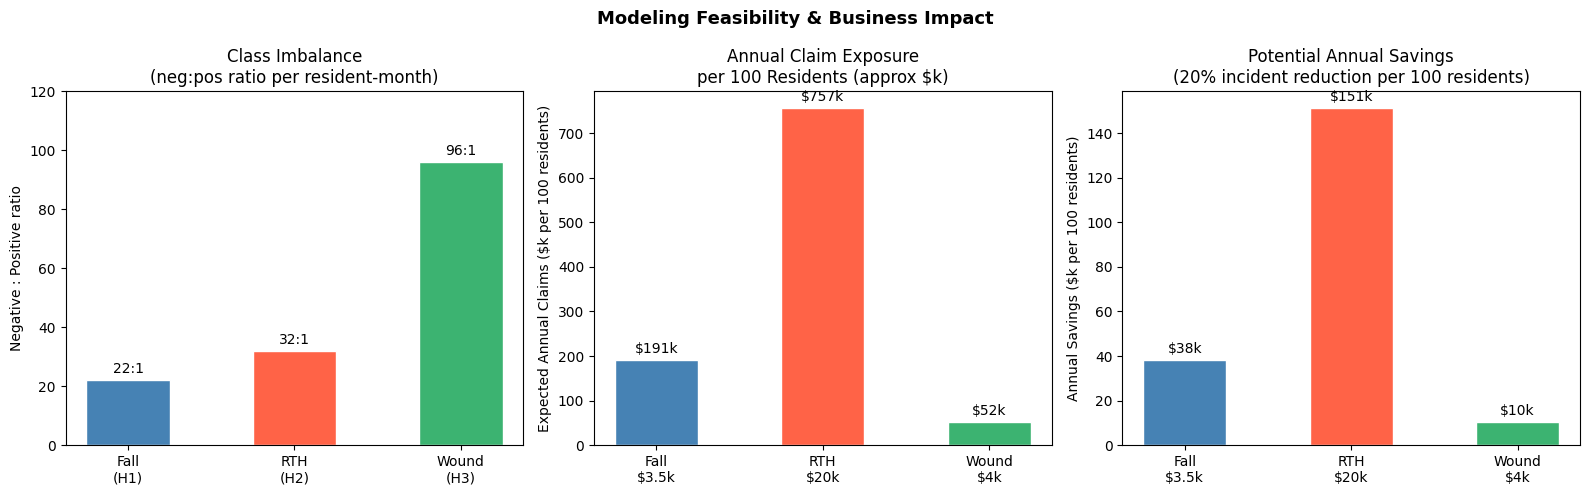

Business impact figure saved.


In [21]:

# ── 6b. Summary figure — expected cost impact per model ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Modeling Feasibility & Business Impact", fontsize=13, fontweight="bold")

# Plot 1: class imbalance (neg:pos ratio)
ax = axes[0]
models = ["Fall\n(H1)", "RTH\n(H2)", "Wound\n(H3)"]
ratios = [22, 32, 96]
colors_m = ["steelblue", "tomato", "mediumseagreen"]
b = ax.bar(models, ratios, color=colors_m, edgecolor="white", width=0.5)
ax.bar_label(b, labels=[f"{r}:1" for r in ratios], padding=3)
ax.set_title("Class Imbalance\n(neg:pos ratio per resident-month)")
ax.set_ylabel("Negative : Positive ratio")
ax.set_ylim(0, 120)

# Plot 2: expected claim cost exposure ($) per 100 residents / year
ax = axes[1]
# Rough estimate: events per 100 residents per year from the 1.5-year window
events_per_100_per_year = {
    "Fall\n$3.5k": 2454 / (3000 / 100) / 1.5,
    "RTH\n$20k": 1703 / (3000 / 100) / 1.5,
    "Wound\n$4k": 587 / (3000 / 100) / 1.5,
}
avg_costs = {"Fall\n$3.5k": 3500, "RTH\n$20k": 20000, "Wound\n$4k": 4000}
labels_c = list(events_per_100_per_year.keys())
claim_exposure = [events_per_100_per_year[l] * avg_costs[l] for l in labels_c]
b2 = ax.bar(labels_c, [c/1000 for c in claim_exposure], color=colors_m, edgecolor="white", width=0.5)
ax.bar_label(b2, labels=[f"${c/1000:.0f}k" for c in claim_exposure], padding=3)
ax.set_title("Annual Claim Exposure\nper 100 Residents (approx $k)")
ax.set_ylabel("Expected Annual Claims ($k per 100 residents)")

# Plot 3: potential savings with 20% reduction (business lever)
ax = axes[2]
savings_20pct = [c * 0.20 / 1000 for c in claim_exposure]
b3 = ax.bar(labels_c, savings_20pct, color=colors_m, edgecolor="white", width=0.5)
ax.bar_label(b3, labels=[f"${s:.0f}k" for s in savings_20pct], padding=3)
ax.set_title("Potential Annual Savings\n(20% incident reduction per 100 residents)")
ax.set_ylabel("Annual Savings ($k per 100 residents)")

plt.tight_layout()
plt.savefig("business_impact.png", dpi=120, bbox_inches="tight")
plt.show()
print("Business impact figure saved.")


## 7. Key EDA Findings & Next Steps

### Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **3,000 residents, 100 facilities** (avg 30/facility). Date range spans 2006–2025, but most clinical signal (vitals, meds, ADL) starts **2023–2024** | Models must use temporal windowing; features restricted to recent window for full-signal training |
| 2 | **Falls dominate** (74% of incidents, 2,505 events). 26.9% of residents had ≥1 fall | Largest training set → most learnable model. Build H1 first |
| 3 | **RTH = highest cost** (~$757k annual exposure per 100 residents). 30.4% of residents had a hospital transfer | H2 is highest-value target; reasonable volume (1,816 transfers) |
| 4 | **Vitals (2.5M rows, 82% coverage)** and **diagnoses (58k rows, 85% coverage)** are the richest features | Use vitals trend features + ICD-10 flags as primary feature groups |
| 5 | **Medication data covers only 16% of residents** (481/3,000) — likely a subset of facilities | Use medication features where available; treat as optional feature group |
| 6 | **ADL/GG data is very sparse** (3–4% of residents, 2024 only) | Useful for the small cohort covered; not a primary feature for most models |
| 7 | **Incident spike post-2023** (monthly chart) — likely reflects both data entry patterns and operational changes | Use this as a temporal covariate; investigate COVID-period anomalies |
| 8 | **Vital outliers present** (BP max=13,385, O2 max=9,994) | Need clipping / Winsorization in feature engineering |
| 9 | **Top ICD-10 codes:** Sarcopenia (M62.81), Hypertension (I10), Difficulty walking (R26.x), Diabetes (E11.9) | Directly map to clinical risk domains (mobility, cardiovascular, metabolic) |
| 10 | **Transfer reasons:** Fall (127), Altered Mental Status (128), SOB (87), Chest Pain (55) | Fall leads to both incidents AND RTH → fall prevention is doubly high-value |

### Next Steps

1. **Feature Engineering Notebook** (`02_feature_engineering.ipynb`)
   - Build resident × 30-day window dataset
   - Vitals: rolling mean, std, trend per vital_type (7d and 30d windows)
   - Diagnoses: Charlson Comorbidity Index + CCS group flags
   - History: incident counts, transfer counts in prior 90/180 days
   - Needs: count of active needs by category

2. **Model Training** (`03_modeling_fall.ipynb`, `04_modeling_rth.ipynb`)
   - LightGBM binary classifiers with temporal CV
   - SHAP feature importance for interpretability
   - Threshold selection for business cost optimization

3. **Composite Risk Score** (`05_risk_score.ipynb`)
   - Combine calibrated probabilities with cost weights
   - Produce facility-level risk reports